In [11]:
from pathlib import Path
from IPython.display import display, Markdown

from resources.imports import *
try:
    import torch
except ModuleNotFoundError:
    torch = None

from resources.MLmetrics import (
    postprocess_resolve_hpo_run_path,
    postprocess_hpo_path_summary,
    postprocess_list_hpo_runs,
    postprocess_cross_hpo_base_path,
    postprocess_load_hpo_study,
    postprocess_hpo_best_overview,
    display_hpo_best_overview,
    postprocess_hpo_trial_leaderboard,
    plot_hpo_optimization_history,
    postprocess_hpo_param_importance,
    plot_hpo_param_importance,
    postprocess_cross_model_hpo_comparison,
    postprocess_select_cross_model_hpo_model,
    plot_cross_model_hpo_comparison,
    postprocess_artifact_table,
    postprocess_load_curve_run,
    postprocess_curve_run_overview,
    display_curve_run_overview,
    postprocess_build_active_curve_diagnostics,
    curve_summary_table,
    display_curve_main_dashboard,
    display_curve_sample_examples,
    postprocess_load_field_run,
    postprocess_field_run_overview,
    display_field_run_overview,
    postprocess_build_active_field_diagnostics,
    field_summary_table,
    plot_field_frame_component_trends,
    plot_field_diversity,
    display_field_sample_error_summary,
    plot_loss_history,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# ML HPO Post-Processing

## 1. Find Recent HPO Runs

In [13]:
FIND_RUN = False
RUN_ROOT = Path(r"Z:/p2")
MAX_RECENT_HPO_RUNS = 25


if FIND_RUN:
    recent_hpo_runs = postprocess_list_hpo_runs(RUN_ROOT, max_runs=MAX_RECENT_HPO_RUNS)
    display(recent_hpo_runs)
    if recent_hpo_runs.empty:
        raise ValueError("No HPO studies with full_study.db were found. Set RUN_PATH_OVERRIDE or update RUN_ROOT.")

## 2. User Configuration

In [14]:
OUTPUT_KIND = "field"  # "curve" or "field"
RUN_TYPE = "cross_model_hpo"  # "model_hpo" or "cross_model_hpo"
TASK = "FT"
mechMode = TASK
MODEL = "auto"  # "auto" selects the best family; or set MLP, GCN, GAT, Transformer.
RUN_NAME = "fFT-fHPO"
run_name = RUN_NAME
RUN_PATH_OVERRIDE = None
STUDY_NAME = None

DATA_PATH_OVERRIDE = None
PREFER_HPO_BEST = True
LOAD_DATA = False
LOAD_MODEL = False
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
ACTIVE_SPLIT = None
VIEW_MODE = None
ZONE_BOUNDARIES = None

CROSS_MODEL_FAMILIES = None  # None discovers folders such as MLP, GCN, GAT, and Transformer.
CROSS_MODEL_SELECTION_METRIC = "best_value"

OUTPUT_KIND = str(OUTPUT_KIND).lower()
if OUTPUT_KIND not in ["curve", "field"]:
    raise ValueError("OUTPUT_KIND must be 'curve' or 'field'.")

RUN_TYPE = str(RUN_TYPE).lower()
if RUN_TYPE not in ["model_hpo", "cross_model_hpo"]:
    raise ValueError("RUN_TYPE must be 'model_hpo' or 'full_hpo'.")

if VIEW_MODE is None:
    VIEW_MODE = TASK if str(TASK).upper() in ["UT", "FT"] else "UT"
VIEW_MODE = str(VIEW_MODE).upper()
if VIEW_MODE not in ["UT", "FT"]:
    raise ValueError("VIEW_MODE must be UT or FT. For MULTI runs, choose which output branch to view.")

cross_model_comparison = None
selected_model_metric = None
selected_model_row = None
requested_model = str(MODEL).strip()

if RUN_TYPE == "cross_model_hpo":
    output_token = {"curve": "Curve", "field": "Field"}[OUTPUT_KIND]
    CROSS_HPO_BASE = Path(RUN_ROOT).expanduser() / str(TASK).upper() / output_token / "HPO" / str(RUN_NAME)
    cross_model_comparison = postprocess_cross_model_hpo_comparison(
        CROSS_HPO_BASE,
        model_names=CROSS_MODEL_FAMILIES,
        task=VIEW_MODE,
    )
    if requested_model.lower() in ["auto", "best", "overall"]:
        selected_model, selected_model_metric, selected_model_row = postprocess_select_cross_model_hpo_model(
            cross_model_comparison,
            preferred_metric=CROSS_MODEL_SELECTION_METRIC,
            task=VIEW_MODE,
        )
        if selected_model is None:
            raise ValueError(f"Could not select a model from cross-model HPO results under {CROSS_HPO_BASE}.")
        MODEL = selected_model
        print(f"Selected MODEL={MODEL} using {selected_model_metric} from the cross-model HPO comparison.")

model = MODEL
RUN_PATH = postprocess_resolve_hpo_run_path(
    run_root=RUN_ROOT,
    task=TASK,
    output_kind=OUTPUT_KIND,
    model=MODEL,
    run_name=RUN_NAME,
    run_type=RUN_TYPE,
    run_path_override=RUN_PATH_OVERRIDE,
)
CROSS_HPO_BASE = postprocess_cross_hpo_base_path(RUN_PATH, run_type=RUN_TYPE)
if RUN_TYPE != "cross_model_hpo":
    CROSS_HPO_BASE = None


Selected MODEL=Transformer using best_value from the cross-model HPO comparison.


## 3. Run And Artifact Discovery

In [15]:
ARTIFACT_TABLE_KEYS = None


display(postprocess_hpo_path_summary(
    RUN_PATH,
    run_root=RUN_ROOT,
    task=TASK,
    output_kind=OUTPUT_KIND,
    model=MODEL,
    run_name=RUN_NAME,
    run_type=RUN_TYPE,
))

if OUTPUT_KIND == "curve":
    artifacts, loaded, DAT, MOD = postprocess_load_curve_run(
        RUN_PATH,
        run_root=RUN_ROOT,
        prefer_hpo_best=PREFER_HPO_BEST,
        load_data=LOAD_DATA,
        load_model=LOAD_MODEL,
        data_path_override=DATA_PATH_OVERRIDE,
        device=DEVICE,
    )
elif OUTPUT_KIND == "field":
    artifacts, loaded, DAT, MOD = postprocess_load_field_run(
        RUN_PATH,
        run_root=RUN_ROOT,
        prefer_hpo_best=PREFER_HPO_BEST,
        load_data=LOAD_DATA,
        load_model=LOAD_MODEL,
        data_path_override=DATA_PATH_OVERRIDE,
        device=DEVICE,
    )


display(postprocess_artifact_table(artifacts, keys=ARTIFACT_TABLE_KEYS))
for warning in artifacts.get("warnings", []):
    print("WARNING:", warning)

,item,value
0,RUN_ROOT,Z:\p2
1,OUTPUT_KIND,field
2,TASK,FT
3,MODEL,Transformer
4,RUN_NAME,fFT-fHPO
5,RUN_TYPE,cross_model_hpo
6,RUN_PATH,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer
7,RUN_PATH_EXISTS,True
8,STUDY_DB,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\full_s...
9,STUDY_DB_EXISTS,True


,artifact,path_or_value
0,input_path,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer
1,run_dir,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer
2,model_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
3,model_mdl,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
4,data_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
5,results_dir,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
6,metrics_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
7,predictions_npz,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
8,loss_history_csv,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
9,diagnostics_summary_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...


## 4. Load Study

In [16]:
study_info = postprocess_load_hpo_study(RUN_PATH, study_name=STUDY_NAME)
study = study_info["study"]

print(study_info["message"])
if not study_info["summaries"].empty:
    display(study_info["summaries"])
if study is None:
    print("Study-dependent HPO summaries will stay empty until full_study.db can be loaded.")

Loaded study 'HPC-Field-CrossModelHPO_Transformer' from Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\full_study.db.


,study_name,direction,n_trials,datetime_start
0,HPC-Field-CrossModelHPO_Transformer,MINIMIZE,81,2026-06-13 11:42:10.218688


## 5. Best Trial Overview

In [17]:
MAX_BEST_USER_ATTRS = 20


best_overview = postprocess_hpo_best_overview(study_info, artifacts=artifacts, loaded=loaded)
display_hpo_best_overview(best_overview, max_attrs=MAX_BEST_USER_ATTRS)

### Best Trial Summary

,item,value
0,study_name,HPC-Field-CrossModelHPO_Transformer
1,direction,MINIMIZE
2,n_trials,81
3,n_complete,24
4,n_pruned,56
5,n_failed,0
6,best_trial,78
7,best_value,0.015321
8,objective_metric,rmse


### Best Parameters

,parameter,value
0,batch,1
1,early_stop,True
2,early_stop_patience,100
3,loss_family,field_mse
4,loss_reduction,mean
5,lr,0.000074
6,objective_metric,rmse
7,optimizer,adamw
8,scheduler,plateau
9,scheduler_factor,0.2


### Best User Attributes

,attribute,value
0,best_model_checkpoint,/gpfs/scratch/exy053/12465873/mlruns/FT/Field/...
1,loss_params,"{""eps"": 1e-12, ""family"": ""field_mse"", ""reducti..."
2,model_params,"{""act"": ""mish"", ""att_dropout"": 0.0684408596057..."
3,task_scores,[0.015321432783778625]
4,train_params,"{""batch"": 1, ""lr"": 7.442834613199463e-05, ""met..."
5,typ,tr


### Best Model Artifacts

,artifact,path_or_value
0,model_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
1,model_mdl,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
2,data_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
3,results_dir,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
4,metrics_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
5,predictions_npz,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
6,loss_history_csv,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
7,diagnostics_summary_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
8,hpo_best_params_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_p...
9,hpo_best_trial_user_attrs_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_t...


## 6. Trial Leaderboard

In [18]:
LEADERBOARD_TOP_N = 20
LEADERBOARD_KEY_PARAMS = None


leaderboard = postprocess_hpo_trial_leaderboard(
    study,
    top_n=LEADERBOARD_TOP_N,
    key_params=LEADERBOARD_KEY_PARAMS,
)
if leaderboard.empty:
    print("No trials are available for the leaderboard.")
else:
    display(leaderboard)

,trial,value,state,model_family,duration_s,lr,tr_att_dropout,tr_dropout,tr_head_dropout,weight_decay,tr_d_model,tr_n_layers,scheduler_factor
0,67,0.000260,PRUNED,NaN,5232.620278,0.000060,0.110051,0.279264,0.042978,1.381260e-09,384,4,0.2
1,54,0.000271,PRUNED,NaN,2814.236320,0.000067,0.038791,0.327969,0.058191,6.900171e-07,192,3,0.2
2,51,0.000276,PRUNED,NaN,1433.274542,0.000100,0.043300,0.283674,0.021071,9.721983e-09,192,5,0.3
3,52,0.000280,PRUNED,NaN,2538.944809,0.000242,0.117033,0.310833,0.103981,7.777837e-08,192,5,0.7
4,49,0.000281,PRUNED,NaN,3314.454574,0.000027,0.212744,0.253281,0.001556,1.607133e-08,192,5,0.2
5,66,0.000284,PRUNED,NaN,4917.498741,0.000018,0.032049,0.102553,0.004302,1.130339e-07,128,5,0.7
6,72,0.000284,PRUNED,NaN,3286.602804,0.000038,0.065238,0.227378,0.042456,5.728740e-09,192,5,0.2
7,61,0.000284,PRUNED,NaN,1947.713851,0.000215,0.105777,0.341132,0.104094,1.303854e-08,256,2,0.2
8,62,0.000288,PRUNED,NaN,4023.094744,0.000032,0.028427,0.273371,0.079395,2.926745e-09,128,5,0.2
9,57,0.000288,PRUNED,NaN,2640.424112,0.000044,0.119300,0.185007,0.024771,2.717145e-08,384,5,0.2


## 7. Optimization History

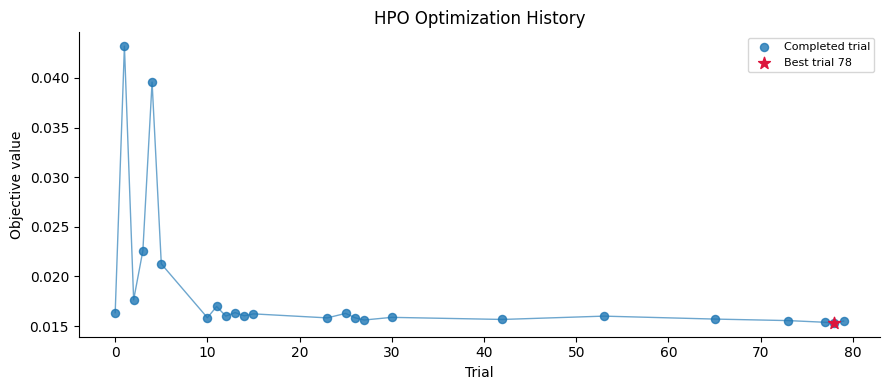

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'HPO Optimization History'}, xlabel='Trial', ylabel='Objective value'>)

In [19]:
OPT_HISTORY_FIGSIZE = (9, 4)


plot_hpo_optimization_history(study, figsize=OPT_HISTORY_FIGSIZE)

## 8. Parameter Importance

,parameter,importance
0,weight_decay,0.304785
1,tr_n_layers,0.132337
2,tr_dropout,0.098790
3,tr_head_dropout,0.090715
4,tr_d_model,0.080181
5,batch,0.076070
6,tr_head_width,0.046405
7,lr,0.045270
8,tr_act,0.039063
9,scheduler_patience,0.023173


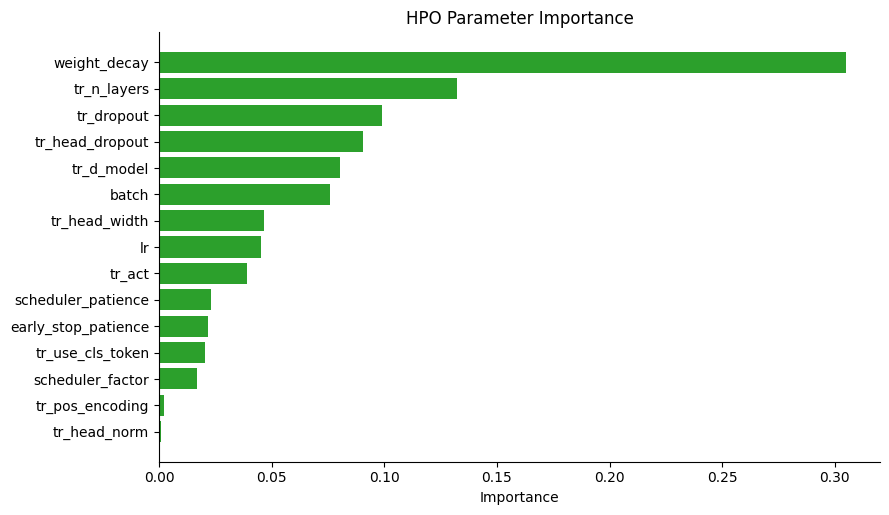

In [20]:
IMPORTANCE_TOP_N = 15
IMPORTANCE_FIGSIZE = None


importance, importance_message = postprocess_hpo_param_importance(study)
if importance_message:
    print(importance_message)
else:
    display(importance)
    plot_hpo_param_importance(importance, top_n=IMPORTANCE_TOP_N, figsize=IMPORTANCE_FIGSIZE)

## 9. Cross-Model Comparison

,model,best_value,best_trial,n_trials,n_complete,n_pruned,n_failed,evaluation_split,FT_best_rmse,FT_val_rmse,FT_summary_rmse,FT_summary_skill_vs_mean_field_rmse
0,Transformer,0.015321,78,81,24,56,0,val,0.015321,0.110204,0.110204,0.264075
1,GAT,0.022004,23,80,15,65,0,val,0.022004,0.146294,0.146294,0.023077
2,GCN,0.022808,56,80,55,25,0,val,0.022808,0.148651,0.148651,0.007334


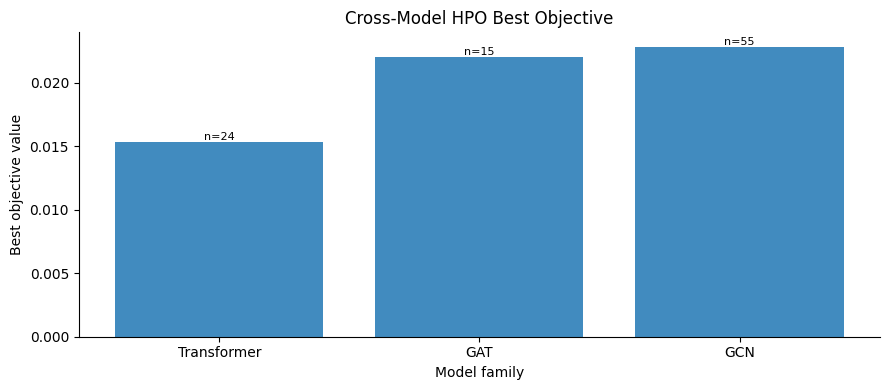

Detailed best-model diagnostics are loaded from MODEL=Transformer.
Model selection metric: best_value


In [21]:
RUN_CROSS_MODEL_COMPARISON = RUN_TYPE == "cross_model_hpo"
SHOW_MODEL_PATHS = False
CROSS_COMPARE_FIGSIZE = (9, 4)


if RUN_CROSS_MODEL_COMPARISON:
    if cross_model_comparison is None:
        cross_model_comparison = postprocess_cross_model_hpo_comparison(
            CROSS_HPO_BASE,
            model_names=CROSS_MODEL_FAMILIES,
            task=VIEW_MODE,
        )
    compact_columns = [
        "model",
        "best_value",
        "best_trial",
        "n_trials",
        "n_complete",
        "n_pruned",
        "n_failed",
        "evaluation_split",
        f"{VIEW_MODE}_best_rmse",
        f"{VIEW_MODE}_val_rmse",
        f"{VIEW_MODE}_summary_rmse",
        f"{VIEW_MODE}_summary_skill_vs_mean_curve_rmse",
        f"{VIEW_MODE}_summary_skill_vs_mean_field_rmse",
    ]
    if SHOW_MODEL_PATHS:
        compact_columns.extend(["study_db", "best_model_json", "results_dir"])
    compact_columns = [col for col in compact_columns if col in cross_model_comparison.columns]
    if cross_model_comparison.empty:
        print("No cross-model HPO folders were found under:", CROSS_HPO_BASE)
    else:
        display(cross_model_comparison[compact_columns])
        plot_cross_model_hpo_comparison(cross_model_comparison, figsize=CROSS_COMPARE_FIGSIZE)
        print(f"Detailed best-model diagnostics are loaded from MODEL={MODEL}.")
        if selected_model_metric is not None:
            print(f"Model selection metric: {selected_model_metric}")
else:
    print("Cross-model comparison is skipped because RUN_TYPE is not 'full_hpo'.")


## 10. Best-Model Run Setup

In [22]:
SHOW_BEST_MODEL_RUN_SETUP = False


if OUTPUT_KIND == "curve":
    best_run_overview = postprocess_curve_run_overview(
        artifacts,
        loaded,
        data=DAT,
        run_name=RUN_NAME,
        run_type=RUN_TYPE,
        mech_mode=TASK,
        view_mode=VIEW_MODE,
        model_name=MODEL,
        device=DEVICE,
        active_split=ACTIVE_SPLIT,
    )
    available_evals = best_run_overview["available_evals"]
    available_output_evals = best_run_overview["available_curve_evals"]
elif OUTPUT_KIND == "field":
    best_run_overview = postprocess_field_run_overview(
        artifacts,
        loaded,
        data=DAT,
        run_name=RUN_NAME,
        run_type=RUN_TYPE,
        mech_mode=TASK,
        view_mode=VIEW_MODE,
        model_name=MODEL,
        device=DEVICE,
        active_split=ACTIVE_SPLIT,
    )
    available_evals = best_run_overview["available_evals"]
    available_output_evals = best_run_overview["available_field_evals"]

ACTIVE_SPLIT = best_run_overview["active_split"]

if SHOW_BEST_MODEL_RUN_SETUP and OUTPUT_KIND == "curve":
    display_curve_run_overview(best_run_overview)
elif SHOW_BEST_MODEL_RUN_SETUP and OUTPUT_KIND == "field":
    display_field_run_overview(best_run_overview)
print("OUTPUT_KIND:", OUTPUT_KIND)
print("VIEW_MODE:", VIEW_MODE)
print("ACTIVE_SPLIT:", ACTIVE_SPLIT)

OUTPUT_KIND: field
VIEW_MODE: FT
ACTIVE_SPLIT: val


## 11. Build Active Best-Model Diagnostics

In [23]:
CURVE_DIAGNOSTIC_METRICS = [
    "rmse",
    "mae",
    "bias",
    "nrmse_range",
    "r2_global",
    "collapse_ratio",
    "mean_curve_baseline_rmse",
    "skill_vs_mean_curve_rmse",
    "mean_sample_curve_corr",
    "peak_corr",
    "peak_x_corr",
    "energy_corr",
    "n_samples",
    "n_points",
]

FIELD_DIAGNOSTIC_METRICS = [
    "rmse",
    "mae",
    "mse",
    "bias",
    "collapse_ratio",
    "mean_field_baseline_rmse",
    "skill_vs_mean_field_rmse",
    "valid_fraction",
    "n_samples",
    "n_frames",
    "n_nodes",
    "n_components",
]

DIAGNOSTIC_LABELS = {
    "rmse": "RMSE",
    "mae": "MAE",
    "mse": "MSE",
    "bias": "bias",
    "nrmse_range": "NRMSE / range",
    "r2_global": "global R2",
    "collapse_ratio": "collapse ratio",
    "mean_curve_baseline_rmse": "mean-curve RMSE",
    "skill_vs_mean_curve_rmse": "skill vs mean curve",
    "mean_sample_curve_corr": "mean sample curve corr.",
    "peak_corr": "peak corr.",
    "peak_x_corr": "peak-x corr.",
    "energy_corr": "energy corr.",
    "mean_field_baseline_rmse": "mean-field RMSE",
    "skill_vs_mean_field_rmse": "skill vs mean field",
    "valid_fraction": "valid fraction",
    "n_samples": "samples",
    "n_points": "curve points",
    "n_frames": "frames",
    "n_nodes": "nodes",
    "n_components": "components",
}


if OUTPUT_KIND == "curve":
    diagnostics, active_key, active_diag = postprocess_build_active_curve_diagnostics(
        DAT,
        loaded,
        available_evals,
        view_mode=VIEW_MODE,
        active_split=ACTIVE_SPLIT,
        model=MOD,
        zone_boundaries=ZONE_BOUNDARIES,
    )
    summary_table = curve_summary_table(active_diag, metrics=CURVE_DIAGNOSTIC_METRICS)
elif OUTPUT_KIND == "field":
    diagnostics, active_key, active_diag = postprocess_build_active_field_diagnostics(
        DAT,
        loaded,
        available_evals,
        view_mode=VIEW_MODE,
        active_split=ACTIVE_SPLIT,
        model=MOD,
    )
    summary_table = field_summary_table(active_diag, metrics=FIELD_DIAGNOSTIC_METRICS)

if active_diag is None:
    print("No active best-model diagnostics are available. Check predictions.npz, diagnostic CSVs, VIEW_MODE, or ACTIVE_SPLIT.")
else:
    display(Markdown(f"**Active diagnostics:** `{active_key[0]} {active_key[1].upper()}`"))

    summary_table = summary_table.copy()
    summary_table["metric"] = summary_table["metric"].replace(DIAGNOSTIC_LABELS)
    summary_table["value"] = summary_table["value"].map(
        lambda value: f"{value:.4g}"
        if isinstance(value, (int, float, np.integer, np.floating)) and np.isfinite(value)
        else value
    )
    display(summary_table)


**Active diagnostics:** `FT VAL`

,metric,value
0,RMSE,0.1102
1,MAE,0.04722
2,MSE,0.01215
3,bias,-0.001516
4,collapse ratio,0.8434
5,mean-field RMSE,0.1497
6,skill vs mean field,0.2641
7,valid fraction,1
8,samples,804
9,frames,20


## 12. Light Best-Model Visual Check

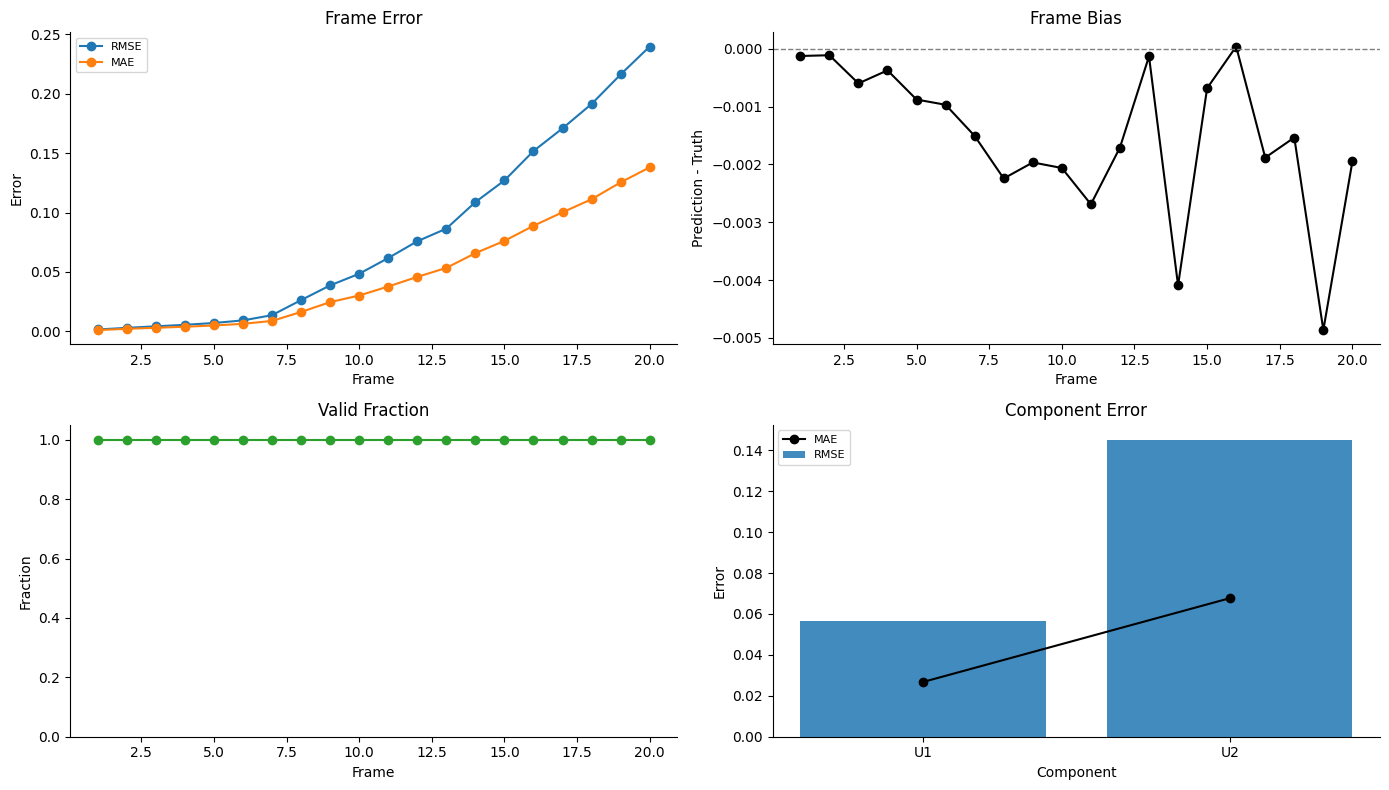

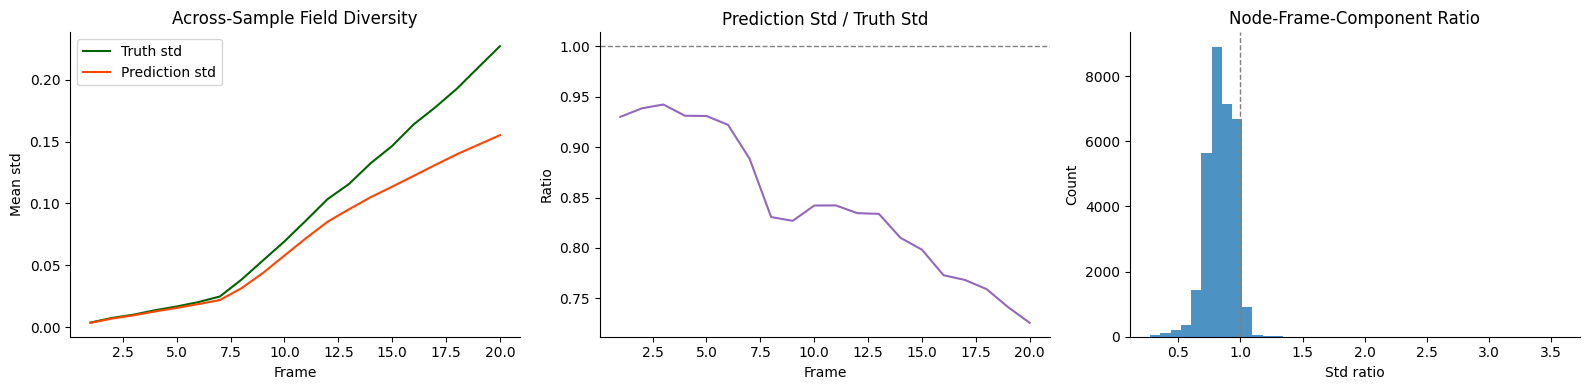

### Best And Worst Samples By RMSE

,sample,sample_mae,sample_mse,sample_rmse,sample_bias,valid_fraction
520,520,0.019675,0.001408,0.037524,0.000794,1.0
199,199,0.022705,0.001616,0.040195,0.006722,1.0
66,66,0.021990,0.001772,0.042098,0.001560,1.0
629,629,0.157558,0.120570,0.347232,0.006399,1.0
627,627,0.171535,0.143227,0.378453,0.106933,1.0
670,670,0.161777,0.152730,0.390807,0.093926,1.0


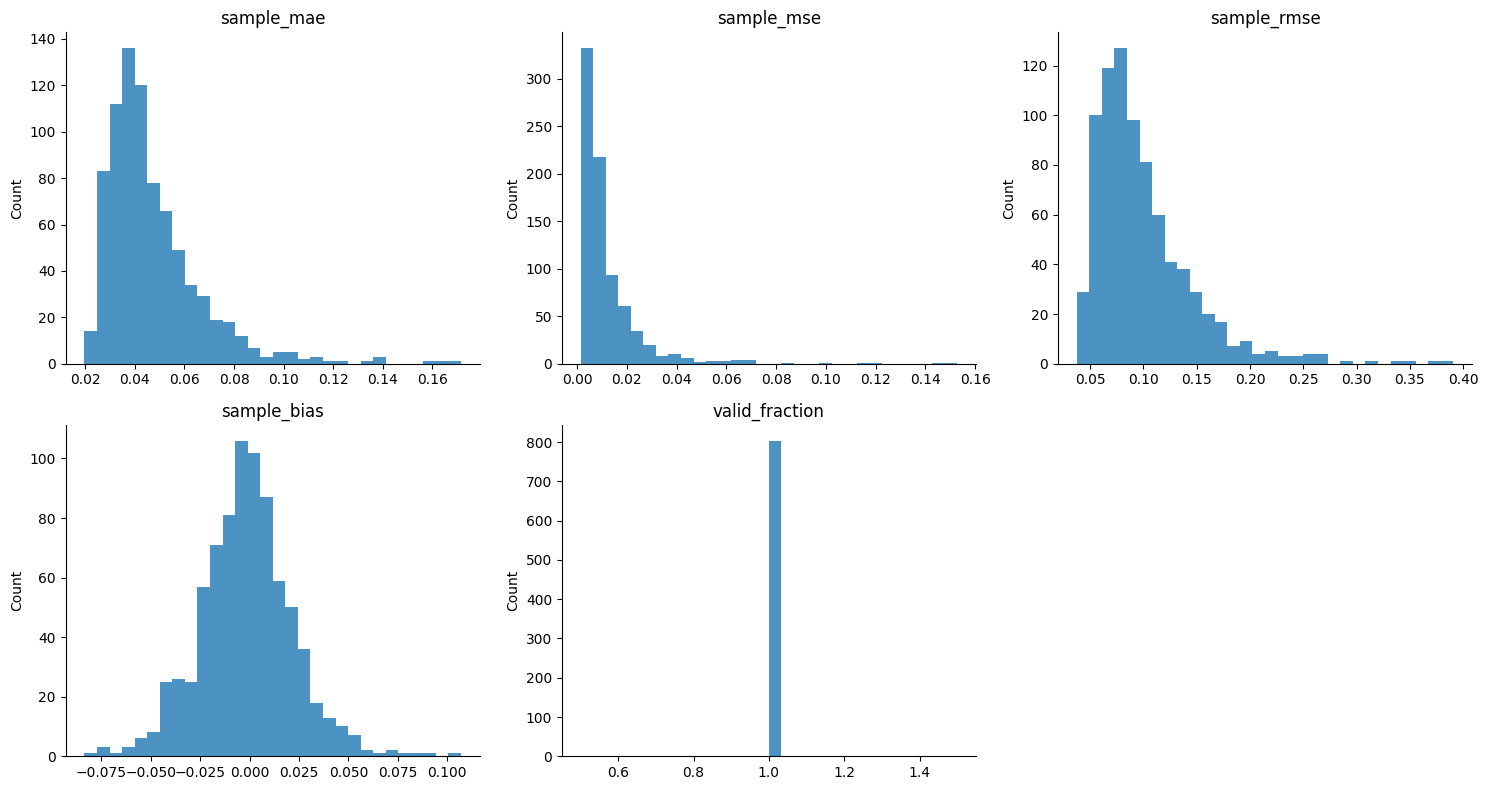

### Sample Metric Summary

,count,mean,std,min,25%,50%,75%,max
sample_mae,804.0,0.047222,0.019550,0.019675,0.034502,0.041995,0.054726,0.171535
sample_mse,804.0,0.012145,0.014431,0.001408,0.004612,0.007663,0.013832,0.152730
sample_rmse,804.0,0.099872,0.046619,0.037524,0.067915,0.087539,0.117612,0.390807
sample_bias,804.0,-0.001516,0.023316,-0.083521,-0.015230,-0.001650,0.011754,0.106933
valid_fraction,804.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
CURVE_DASHBOARD_MAX_SAMPLES = 32
CURVE_DASHBOARD_SORT_BY = "rmse"
SHOW_CURVE_SAMPLE_EXAMPLES = True
CURVE_SELECTED_SAMPLE = 0
CURVE_RANDOM_SAMPLE_COUNT = 4
CURVE_RANDOM_SEED = 42

FIELD_FRAME_TRENDS_FIGSIZE = (14, 8)
FIELD_SHOW_DIVERSITY = True
FIELD_DIVERSITY_FIGSIZE = (16, 4)
FIELD_SAMPLE_TABLE_TOP_N = 3
FIELD_SAMPLE_DISTRIBUTION_BINS = 30


if active_diag is None:
    print("No active best-model diagnostics are available.")
elif OUTPUT_KIND == "curve":
    display_curve_main_dashboard(
        active_diag,
        data=DAT,
        mode=active_key[0] if active_key is not None else VIEW_MODE,
        max_samples=CURVE_DASHBOARD_MAX_SAMPLES,
        sort_by=CURVE_DASHBOARD_SORT_BY,
    )
    if SHOW_CURVE_SAMPLE_EXAMPLES:
        display_curve_sample_examples(
            active_diag,
            selected_sample=CURVE_SELECTED_SAMPLE,
            random_count=CURVE_RANDOM_SAMPLE_COUNT,
            random_seed=CURVE_RANDOM_SEED,
            rank_by="sample_rmse",
            ncols=2,
        )
elif OUTPUT_KIND == "field":
    plot_field_frame_component_trends(active_diag, figsize=FIELD_FRAME_TRENDS_FIGSIZE)
    if FIELD_SHOW_DIVERSITY:
        try:
            plot_field_diversity(active_diag, figsize=FIELD_DIVERSITY_FIGSIZE)
        except ValueError as exc:
            print(exc)
    display_field_sample_error_summary(
        active_diag,
        bins=FIELD_SAMPLE_DISTRIBUTION_BINS,
        ncols=3,
        top_n=FIELD_SAMPLE_TABLE_TOP_N,
        columns=["sample_mae", "sample_mse", "sample_rmse", "sample_bias", "valid_fraction"],
    )

## 13. Best-Model Loss History

,mode,epoch,train_loss,val_loss
0,FT,1,0.014355,0.001221
1,FT,2,0.001311,0.001100
2,FT,3,0.000853,0.000759
3,FT,4,0.000646,0.000656
4,FT,5,0.000534,0.000484


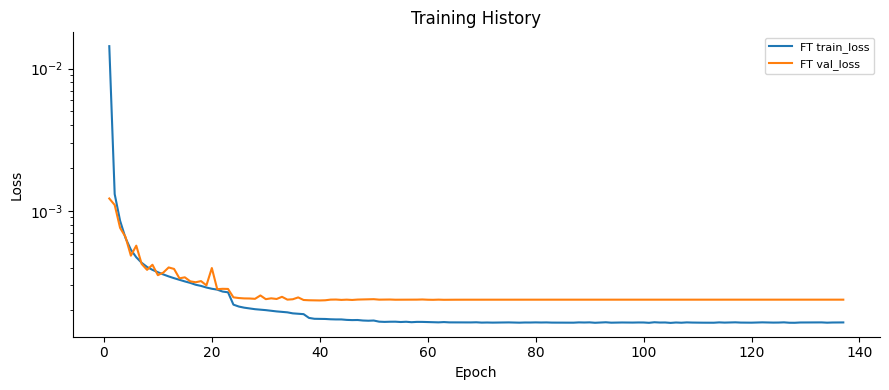

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Training History'}, xlabel='Epoch', ylabel='Loss'>)

In [25]:
LOSS_HISTORY_METRICS = ["train_loss", "val_loss"]
LOSS_HISTORY_FIGSIZE = (9, 4)


loss_history = loaded.get("loss_history")
if loss_history is not None and hasattr(loss_history, "empty") and not loss_history.empty:
    display(loss_history.head())
plot_loss_history(loss_history, metrics=LOSS_HISTORY_METRICS, figsize=LOSS_HISTORY_FIGSIZE)